# GabesHeal — F2 : Détection d'anomalies des plantes
## Fine-tuning ResNet-50 sur New Plant Diseases Dataset

**Hackathon H12 Innovation 3.0 — AI Healing Gabès**

Ce notebook entraîne un modèle ResNet-50 fine-tuné pour détecter 38 classes de maladies végétales,  
avec Grad-CAM pour visualiser la zone malade sur la photo originale.

---
**Dataset** : `vipoooool/new-plant-diseases-dataset` (87 900 images, 38 classes)  
**Modèle** : ResNet-50 (ImageNet) → fine-tuning 2 phases  
**Output** : Modèle `.pth` + fonction de prédiction + heatmap Grad-CAM

## 0. Configuration Kaggle
Active le GPU dans : **Settings → Accelerator → GPU T4 x2**

In [6]:
import os
import torch

# Vérification GPU
print('GPU disponible :', torch.cuda.is_available())
print('Nom GPU        :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Aucun')
print('CUDA version   :', torch.version.cuda)

# Chemin dataset Kaggle
DATA_DIR = '/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VALID_DIR = os.path.join(DATA_DIR, 'valid')

print('\nNombre de classes :', len(os.listdir(TRAIN_DIR)))
print('Dossiers train    :', sorted(os.listdir(TRAIN_DIR))[:5], '...')

GPU disponible : True
Nom GPU        : Tesla T4
CUDA version   : 12.8

Nombre de classes : 38
Dossiers train    : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy'] ...


## 1. Imports

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import json
import time
import copy
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, models, transforms

import cv2
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device utilisé :', DEVICE)

Device utilisé : cuda


## 2. Exploration du dataset

In [8]:
classes = sorted(os.listdir(TRAIN_DIR))
num_classes = len(classes)

# Compter les images par classe
class_counts = {}
for cls in classes:
    path = os.path.join(TRAIN_DIR, cls)
    class_counts[cls] = len(os.listdir(path))

# Séparer plantes saines vs malades
healthy = {k: v for k, v in class_counts.items() if 'healthy' in k.lower()}
diseased = {k: v for k, v in class_counts.items() if 'healthy' not in k.lower()}

print(f'Total classes          : {num_classes}')
print(f'Classes saines         : {len(healthy)}')
print(f'Classes malades        : {len(diseased)}')
print(f'Total images train     : {sum(class_counts.values()):,}')
print()

# Filtrer les plantes pertinentes pour Gabès
GABES_PLANTS = ['Tomato', 'Pepper', 'Potato', 'Grape', 'Corn']
gabes_classes = [c for c in classes if any(p in c for p in GABES_PLANTS)]
print(f'Classes pertinentes pour Gabès ({len(gabes_classes)}) :')
for c in gabes_classes:
    print(f'  {c} : {class_counts[c]} images')

Total classes          : 38
Classes saines         : 12
Classes malades        : 26
Total images train     : 70,295

Classes pertinentes pour Gabès (23) :
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 1642 images
  Corn_(maize)___Common_rust_ : 1907 images
  Corn_(maize)___Northern_Leaf_Blight : 1908 images
  Corn_(maize)___healthy : 1859 images
  Grape___Black_rot : 1888 images
  Grape___Esca_(Black_Measles) : 1920 images
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 1722 images
  Grape___healthy : 1692 images
  Pepper,_bell___Bacterial_spot : 1913 images
  Pepper,_bell___healthy : 1988 images
  Potato___Early_blight : 1939 images
  Potato___Late_blight : 1939 images
  Potato___healthy : 1824 images
  Tomato___Bacterial_spot : 1702 images
  Tomato___Early_blight : 1920 images
  Tomato___Late_blight : 1851 images
  Tomato___Leaf_Mold : 1882 images
  Tomato___Septoria_leaf_spot : 1745 images
  Tomato___Spider_mites Two-spotted_spider_mite : 1741 images
  Tomato___Target_Spot :

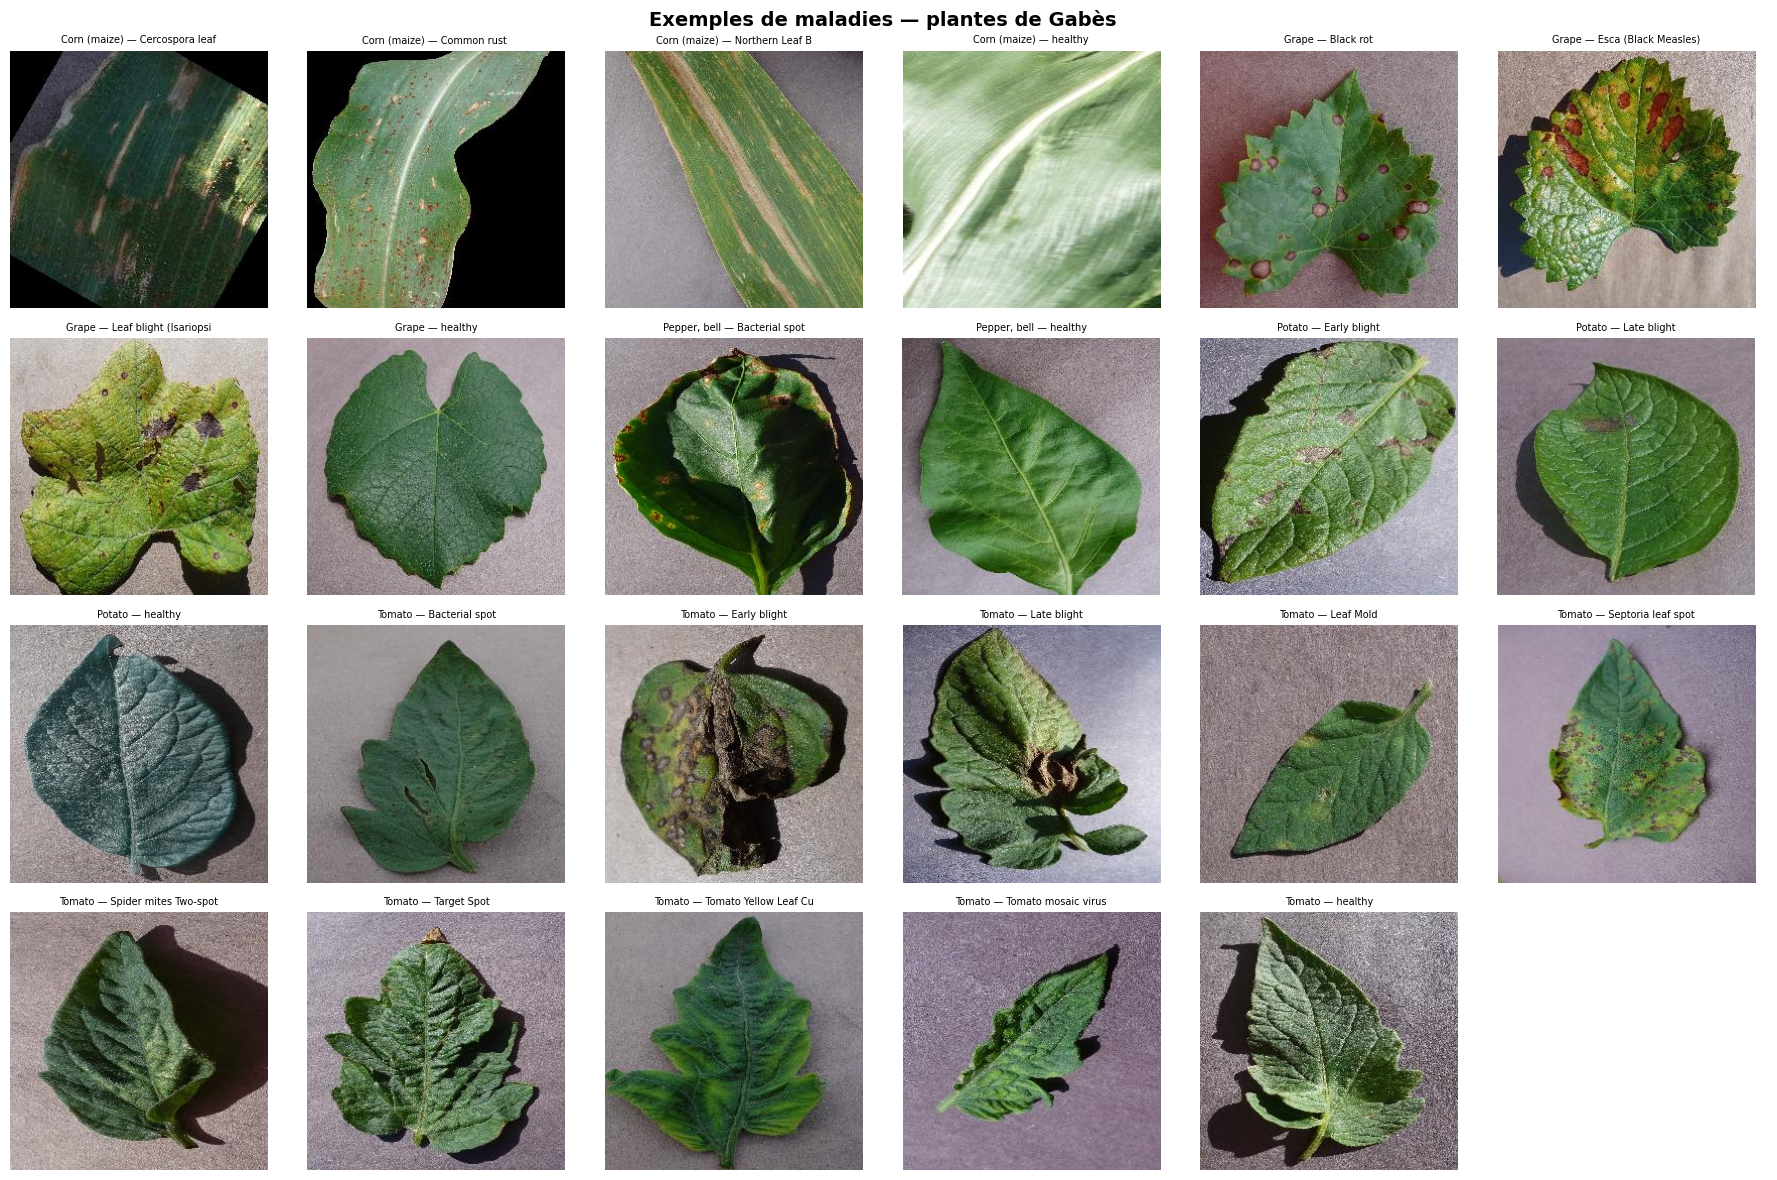

In [9]:
# Visualiser des exemples de chaque type de maladie
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
axes = axes.flatten()

for i, cls in enumerate(gabes_classes[:24]):
    img_dir = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(img_dir)[0]
    img = Image.open(os.path.join(img_dir, img_file)).convert('RGB')
    axes[i].imshow(img)
    # Nom court pour affichage
    label = cls.replace('___', ' — ').replace('_', ' ')
    axes[i].set_title(label[:30], fontsize=7)
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Exemples de maladies — plantes de Gabès', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/samples_gabes.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Prétraitement & DataLoaders

In [10]:
# Hyperparamètres
IMG_SIZE   = 224       # ResNet attend 224×224
BATCH_SIZE = 64        # Ajuster selon mémoire GPU (32 si OOM)
NUM_EPOCHS_PHASE1 = 5  # Phase 1 : tête seulement
NUM_EPOCHS_PHASE2 = 10 # Phase 2 : tout le réseau
LR_PHASE1  = 1e-3
LR_PHASE2  = 1e-4

# Normalisation ImageNet (OBLIGATOIRE pour transfer learning)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transformations : augmentation forte pour train, minimale pour val
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(
            brightness=0.3, contrast=0.3,
            saturation=0.3, hue=0.1
        ),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])
}

# Datasets
image_datasets = {
    'train': datasets.ImageFolder(TRAIN_DIR, data_transforms['train']),
    'valid': datasets.ImageFolder(VALID_DIR, data_transforms['valid'])
}

dataloaders = {
    split: DataLoader(
        image_datasets[split],
        batch_size=BATCH_SIZE,
        shuffle=(split == 'train'),
        num_workers=4,
        pin_memory=True
    )
    for split in ['train', 'valid']
}

dataset_sizes = {s: len(image_datasets[s]) for s in ['train', 'valid']}
class_names   = image_datasets['train'].classes
CLASS_TO_IDX  = image_datasets['train'].class_to_idx
IDX_TO_CLASS  = {v: k for k, v in CLASS_TO_IDX.items()}

# Sauvegarder le mapping pour l'API
with open('/kaggle/working/class_mapping.json', 'w') as f:
    json.dump(IDX_TO_CLASS, f, ensure_ascii=False, indent=2)

print(f'Train : {dataset_sizes["train"]:,} images')
print(f'Valid : {dataset_sizes["valid"]:,} images')
print(f'Classes : {len(class_names)}')

Train : 70,295 images
Valid : 17,572 images
Classes : 38


## 4. Architecture ResNet-50 fine-tuné

**Stratégie 2 phases :**
- **Phase 1** : Geler tout le backbone, entraîner seulement la tête FC (5 epochs)
- **Phase 2** : Dégeler les dernières couches, entraîner avec LR faible (10 epochs)


In [11]:
def build_resnet50(num_classes, freeze_backbone=True):
    """
    Construit ResNet-50 pré-entraîné ImageNet
    avec une tête de classification personnalisée.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    if freeze_backbone:
        # Phase 1 : geler tout le backbone
        for param in model.parameters():
            param.requires_grad = False

    # Remplacer la tête FC par notre classifieur
    in_features = model.fc.in_features  # 2048 pour ResNet-50
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )

    return model.to(DEVICE)


def unfreeze_last_layers(model, num_layers=2):
    """
    Phase 2 : dégèle les derniers blocs ResNet pour fine-tuning profond.
    num_layers=2 → dégèle layer4 + layer3
    """
    layers_to_unfreeze = ['layer4', 'layer3', 'layer2', 'layer1'][:num_layers]

    for name, param in model.named_parameters():
        for layer in layers_to_unfreeze:
            if layer in name:
                param.requires_grad = True

    # Toujours entraîner la tête FC
    for param in model.fc.parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Paramètres entraînables : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')


# Construire le modèle Phase 1
model = build_resnet50(num_classes=len(class_names), freeze_backbone=True)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Phase 1 — paramètres entraînables : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')
print('Architecture tête FC :', model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s] 


Phase 1 — paramètres entraînables : 1,068,582 / 24,576,614 (4.3%)
Architecture tête FC : Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=512, out_features=38, bias=True)
)


## 5. Fonction d'entraînement

In [12]:
def train_model(model, criterion, optimizer, scheduler, num_epochs, phase_name=''):
    """
    Boucle d'entraînement avec early stopping et sauvegarde du meilleur modèle.
    Retourne le modèle et l'historique des métriques.
    """
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f'\n=== {phase_name} — {num_epochs} epochs ===')

    for epoch in range(num_epochs):
        t0 = time.time()
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 40)

        for phase in ['train', 'valid']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects.double() / dataset_sizes[phase]

            key = 'train' if phase == 'train' else 'val'
            history[f'{key}_loss'].append(epoch_loss)
            history[f'{key}_acc'].append(epoch_acc.item())

            print(f'  {phase:5s} — Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')

            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
                print(f'  Nouveau meilleur modèle sauvegardé (acc={best_acc:.4f})')

        print(f'  Durée epoch : {(time.time()-t0)/60:.1f} min')

    print(f'\nMeilleure accuracy validation : {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history

## 6. Entraînement Phase 1 — tête FC uniquement

In [13]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Phase 1 : optimizer sur FC seulement
optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1,
    weight_decay=1e-4
)
scheduler_p1 = lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=NUM_EPOCHS_PHASE1)

model, history_p1 = train_model(
    model, criterion, optimizer_p1, scheduler_p1,
    num_epochs=NUM_EPOCHS_PHASE1,
    phase_name='Phase 1 — Tête FC'
)


=== Phase 1 — Tête FC — 5 epochs ===

Epoch 1/5
----------------------------------------
  train — Loss: 1.2789  Acc: 0.8435
  valid — Loss: 0.9955  Acc: 0.9381
  Nouveau meilleur modèle sauvegardé (acc=0.9381)
  Durée epoch : 6.8 min

Epoch 2/5
----------------------------------------
  train — Loss: 1.0467  Acc: 0.9161
  valid — Loss: 0.9523  Acc: 0.9471
  Nouveau meilleur modèle sauvegardé (acc=0.9471)
  Durée epoch : 6.0 min

Epoch 3/5
----------------------------------------
  train — Loss: 1.0012  Acc: 0.9300
  valid — Loss: 0.9131  Acc: 0.9586
  Nouveau meilleur modèle sauvegardé (acc=0.9586)
  Durée epoch : 6.0 min

Epoch 4/5
----------------------------------------
  train — Loss: 0.9746  Acc: 0.9400
  valid — Loss: 0.9047  Acc: 0.9595
  Nouveau meilleur modèle sauvegardé (acc=0.9595)
  Durée epoch : 6.1 min

Epoch 5/5
----------------------------------------
  train — Loss: 0.9530  Acc: 0.9466
  valid — Loss: 0.8874  Acc: 0.9661
  Nouveau meilleur modèle sauvegardé (acc=0.96

## 7. Entraînement Phase 2 — fine-tuning profond

In [14]:
# Dégeler les 2 derniers blocs ResNet
unfreeze_last_layers(model, num_layers=2)

# Phase 2 : LR beaucoup plus faible pour ne pas écraser les poids pré-entraînés
optimizer_p2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE2,
    weight_decay=1e-4
)
scheduler_p2 = lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=NUM_EPOCHS_PHASE2)

model, history_p2 = train_model(
    model, criterion, optimizer_p2, scheduler_p2,
    num_epochs=NUM_EPOCHS_PHASE2,
    phase_name='Phase 2 — Fine-tuning profond'
)

Paramètres entraînables : 23,131,686 / 24,576,614 (94.1%)

=== Phase 2 — Fine-tuning profond — 10 epochs ===

Epoch 1/10
----------------------------------------
  train — Loss: 0.8282  Acc: 0.9792
  valid — Loss: 0.7442  Acc: 0.9917
  Nouveau meilleur modèle sauvegardé (acc=0.9917)
  Durée epoch : 9.6 min

Epoch 2/10
----------------------------------------
  train — Loss: 0.7560  Acc: 0.9917
  valid — Loss: 0.7121  Acc: 0.9949
  Nouveau meilleur modèle sauvegardé (acc=0.9949)
  Durée epoch : 9.6 min

Epoch 3/10
----------------------------------------
  train — Loss: 0.7302  Acc: 0.9941
  valid — Loss: 0.6992  Acc: 0.9955
  Nouveau meilleur modèle sauvegardé (acc=0.9955)
  Durée epoch : 9.5 min

Epoch 4/10
----------------------------------------
  train — Loss: 0.7175  Acc: 0.9952
  valid — Loss: 0.6930  Acc: 0.9960
  Nouveau meilleur modèle sauvegardé (acc=0.9960)
  Durée epoch : 9.5 min

Epoch 5/10
----------------------------------------
  train — Loss: 0.7088  Acc: 0.9965
  vali

## 8. Courbes d'entraînement

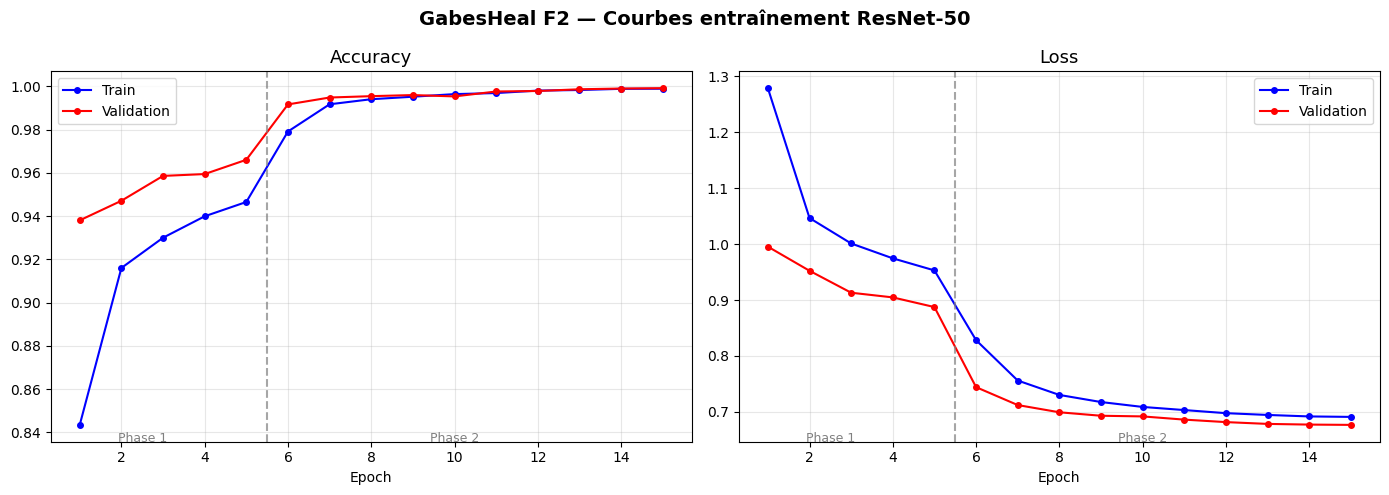

Meilleure val accuracy : 99.92%


In [15]:
def plot_history(h1, h2):
    # Combiner les deux phases
    train_acc  = h1['train_acc']  + h2['train_acc']
    val_acc    = h1['val_acc']    + h2['val_acc']
    train_loss = h1['train_loss'] + h2['train_loss']
    val_loss   = h1['val_loss']   + h2['val_loss']
    epochs     = range(1, len(train_acc) + 1)
    p1_end     = len(h1['train_acc'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for ax, train_vals, val_vals, title in [
        (ax1, train_acc,  val_acc,  'Accuracy'),
        (ax2, train_loss, val_loss, 'Loss')
    ]:
        ax.plot(epochs, train_vals, 'b-o', markersize=4, label='Train')
        ax.plot(epochs, val_vals,   'r-o', markersize=4, label='Validation')
        ax.axvline(p1_end + 0.5, color='gray', linestyle='--', alpha=0.7)
        ax.text(p1_end * 0.5, ax.get_ylim()[0], 'Phase 1',
                ha='center', fontsize=9, color='gray')
        ax.text(p1_end + (len(epochs)-p1_end)*0.5, ax.get_ylim()[0], 'Phase 2',
                ha='center', fontsize=9, color='gray')
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle('GabesHeal F2 — Courbes entraînement ResNet-50', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Meilleure val accuracy : {max(val_acc)*100:.2f}%')

plot_history(history_p1, history_p2)

## 9. Grad-CAM — visualiser la zone malade

Grad-CAM produit une heatmap qui montre **exactement quelle zone de la feuille**  
a déclenché la prédiction du modèle. C'est l'élément visuel clé pour la démo au jury.

In [16]:
class GradCAM:
    """
    Implémentation de Grad-CAM pour ResNet-50.
    Capture les gradients de la dernière couche conv (layer4).
    """
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        # Hook sur la dernière couche convolutionnelle de ResNet-50
        target_layer = self.model.layer4[-1]

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def generate(self, img_tensor, class_idx=None):
        """
        Génère la heatmap Grad-CAM pour une image.
        img_tensor : [1, 3, 224, 224] tenseur normalisé
        """
        self.model.eval()
        img_tensor = img_tensor.to(DEVICE)
        img_tensor.requires_grad_(True)

        # Forward pass
        output = self.model(img_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Backward sur la classe prédite
        self.model.zero_grad()
        output[0, class_idx].backward()

        # Calculer les poids d'importance
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # [1, 2048, 1, 1]
        cam     = (weights * self.activations).sum(dim=1).squeeze()  # [7, 7]
        cam     = torch.relu(cam)

        # Normaliser et redimensionner à 224×224
        cam = cam.cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (224, 224))

        return cam, class_idx, output.softmax(dim=1)[0, class_idx].item()


def denormalize(tensor):
    """Inverse la normalisation ImageNet pour affichage."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img  = tensor.cpu().squeeze() * std + mean
    return img.permute(1, 2, 0).numpy().clip(0, 1)


def overlay_heatmap(img_np, cam, alpha=0.45):
    """Superpose la heatmap Grad-CAM sur l'image originale."""
    heatmap = cm.jet(cam)[:, :, :3]  # [224,224,3] RGB
    return (1 - alpha) * img_np + alpha * heatmap


print('GradCAM initialisé')
grad_cam = GradCAM(model)

GradCAM initialisé


Image test : Tomato___Early_blight


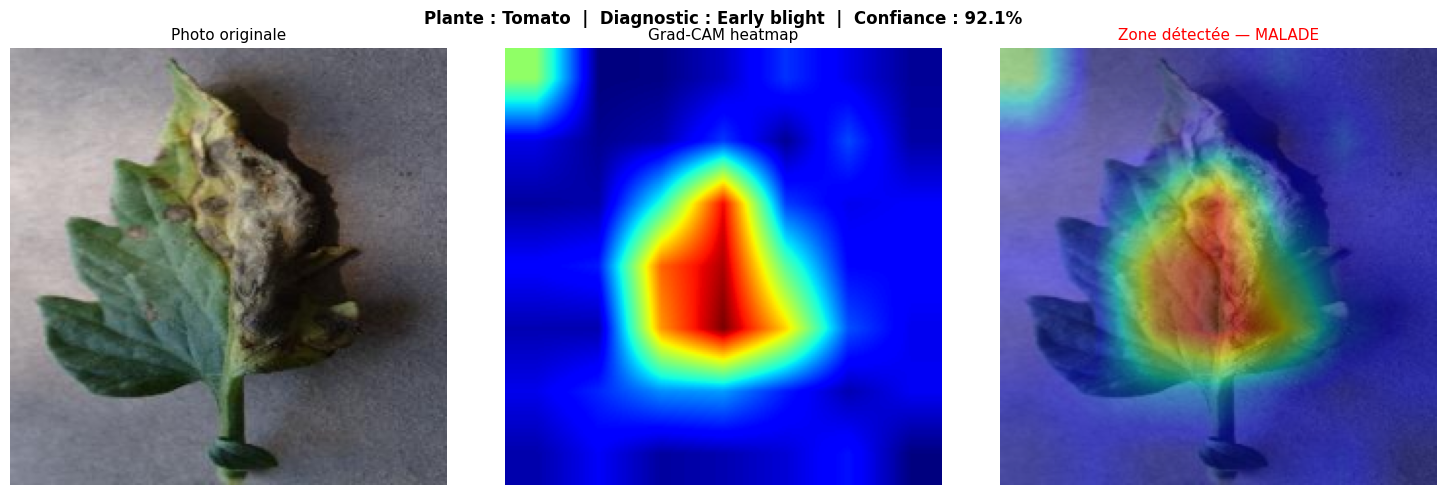


RAPPORT DIAGNOSTIC GABESEAL F2
Plante       : Tomato
Diagnostic   : Early blight
Confiance    : 92.1%
Statut       : MALADE

Top 3 probabilités :
  Tomato — Early blight                     92.1% ███████████████████████████
  Corn (maize) — Northern Leaf Blight        0.3% 
  Orange — Haunglongbing (Citrus greening)   0.3% 


('Tomato___Early_blight', 0.9213861227035522)

In [17]:
def predict_and_visualize(image_path, top_k=3):
    """
    Fonction principale de démo :
    - Prédit la maladie depuis une photo
    - Génère la heatmap Grad-CAM
    - Affiche le rapport de diagnostic
    """
    # Charger et transformer l'image
    img = Image.open(image_path).convert('RGB')
    img_tensor = data_transforms['valid'](img).unsqueeze(0)

    # Grad-CAM
    cam, pred_idx, confidence = grad_cam.generate(img_tensor)

    # Top-K prédictions
    with torch.no_grad():
        outputs = model(img_tensor.to(DEVICE))
        probs   = outputs.softmax(dim=1)[0].cpu()
        topk    = torch.topk(probs, k=top_k)

    pred_class = IDX_TO_CLASS[pred_idx]
    plant_name, condition = pred_class.split('___') if '___' in pred_class else (pred_class, 'Unknown')
    is_healthy = 'healthy' in condition.lower()

    # Affichage
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Image originale
    img_resized = img.resize((224, 224))
    axes[0].imshow(img_resized)
    axes[0].set_title('Photo originale', fontsize=11)
    axes[0].axis('off')

    # Heatmap seule
    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title('Grad-CAM heatmap', fontsize=11)
    axes[1].axis('off')

    # Superposition
    img_np   = np.array(img_resized) / 255.0
    overlaid = overlay_heatmap(img_np, cam)
    axes[2].imshow(overlaid)
    title_color = 'green' if is_healthy else 'red'
    status = 'SAINE' if is_healthy else 'MALADE'
    axes[2].set_title(f'Zone détectée — {status}', fontsize=11, color=title_color)
    axes[2].axis('off')

    plt.suptitle(
        f'Plante : {plant_name}  |  Diagnostic : {condition.replace("_", " ")}  |  Confiance : {confidence*100:.1f}%',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('/kaggle/working/gradcam_result.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Rapport structuré
    print('\n' + '='*50)
    print('RAPPORT DIAGNOSTIC GABESEAL F2')
    print('='*50)
    print(f'Plante       : {plant_name}')
    print(f'Diagnostic   : {condition.replace("_", " ")}')
    print(f'Confiance    : {confidence*100:.1f}%')
    print(f'Statut       : {status}')
    print()
    print('Top 3 probabilités :')
    for idx, prob in zip(topk.indices.numpy(), topk.values.numpy()):
        cls_name = IDX_TO_CLASS[idx].replace('___', ' — ').replace('_', ' ')
        bar = '█' * int(prob * 30)
        print(f'  {cls_name[:40]:<40} {prob*100:5.1f}% {bar}')
    print('='*50)

    return pred_class, confidence


# Démo sur une image de test du dataset
test_classes = [c for c in os.listdir(VALID_DIR) if 'Tomato' in c]
test_class   = test_classes[2]  # Prendre une classe malade
test_img_dir = os.path.join(VALID_DIR, test_class)
test_img     = os.path.join(test_img_dir, os.listdir(test_img_dir)[0])

print(f'Image test : {test_class}')
predict_and_visualize(test_img)

## 10. Évaluation complète sur la validation

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, dataloader):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs  = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)


preds, labels = evaluate_model(model, dataloaders['valid'])
accuracy = (preds == labels).mean()
print(f'\nAccuracy globale : {accuracy*100:.2f}%')

# Rapport par classe
print('\nRapport de classification (10 premières classes) :')
report = classification_report(
    labels, preds,
    target_names=class_names,
    output_dict=True
)

# Top 10 classes avec la meilleure F1-score
df_report = pd.DataFrame(report).T.iloc[:-3]
df_report = df_report.sort_values('f1-score', ascending=False)
print(df_report.head(10)[['precision', 'recall', 'f1-score']].round(3).to_string())


Accuracy globale : 99.92%

Rapport de classification (10 premières classes) :
                                          precision  recall  f1-score
Apple___Apple_scab                              1.0     1.0       1.0
Apple___Black_rot                               1.0     1.0       1.0
Apple___Cedar_apple_rust                        1.0     1.0       1.0
Apple___healthy                                 1.0     1.0       1.0
Blueberry___healthy                             1.0     1.0       1.0
Cherry_(including_sour)___Powdery_mildew        1.0     1.0       1.0
Cherry_(including_sour)___healthy               1.0     1.0       1.0
Corn_(maize)___Common_rust_                     1.0     1.0       1.0
Grape___Black_rot                               1.0     1.0       1.0
Corn_(maize)___healthy                          1.0     1.0       1.0


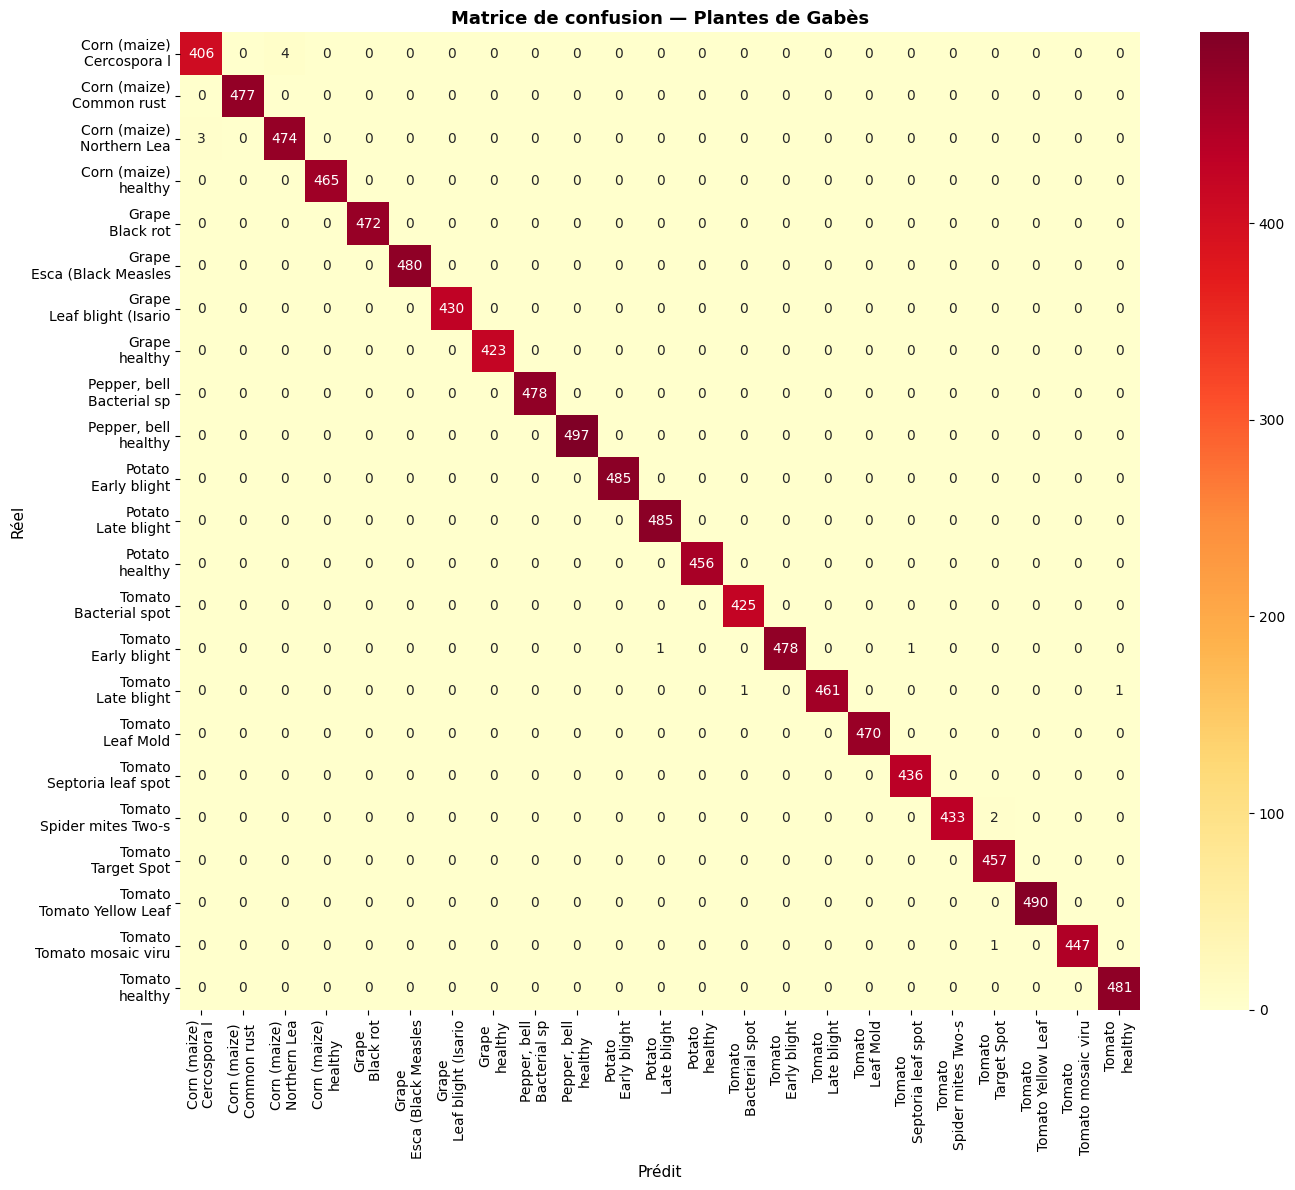

In [19]:
# Matrice de confusion — plantes de Gabès seulement
gabes_indices = [CLASS_TO_IDX[c] for c in class_names
                 if any(p in c for p in GABES_PLANTS)]
gabes_names_short = [
    c.replace('___', '\n').replace('_', ' ')[:25]
    for c in class_names
    if any(p in c for p in GABES_PLANTS)
]

mask_val = np.isin(labels, gabes_indices)
cm_gabes = confusion_matrix(
    labels[mask_val], preds[mask_val],
    labels=gabes_indices
)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_gabes, annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=gabes_names_short,
    yticklabels=gabes_names_short,
    ax=ax
)
ax.set_title('Matrice de confusion — Plantes de Gabès', fontsize=13, fontweight='bold')
ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel',   fontsize=11)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_gabes.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Export du modèle pour l'API FastAPI

In [20]:
# Sauvegarder tout ce dont l'API a besoin
export = {
    'model_state_dict': model.state_dict(),
    'class_to_idx': CLASS_TO_IDX,
    'idx_to_class': IDX_TO_CLASS,
    'num_classes': len(class_names),
    'img_size': IMG_SIZE,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std': IMAGENET_STD,
}

torch.save(export, '/kaggle/working/gabeseal_f2_model.pth')
print('Modèle exporté : /kaggle/working/gabeseal_f2_model.pth')

# Vérification des fichiers produits
output_files = list(Path('/kaggle/working').glob('*'))
print('\nFichiers générés :')
for f in sorted(output_files):
    size = f.stat().st_size / 1024**2
    print(f'  {f.name:<35} {size:.1f} MB')

Modèle exporté : /kaggle/working/gabeseal_f2_model.pth

Fichiers générés :
  .virtual_documents                  0.0 MB
  best_model.pth                      94.1 MB
  class_mapping.json                  0.0 MB
  confusion_matrix_gabes.png          0.2 MB
  gabeseal_f2_model.pth               94.1 MB
  gradcam_result.png                  0.7 MB
  samples_gabes.png                   4.0 MB
  training_curves.png                 0.1 MB


## 12. Snippet de chargement pour l'API FastAPI

Ce code est à coller directement dans ton backend `main.py`.

In [21]:
FASTAPI_SNIPPET = '''
# ─── À coller dans ton main.py FastAPI ─────────────────────────────────────

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import io

# Charger le modèle au démarrage
checkpoint = torch.load("gabeseal_f2_model.pth", map_location="cpu")
model = models.resnet50()
model.fc = torch.nn.Sequential(
    torch.nn.Linear(2048, 512),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.4),
    torch.nn.Linear(512, checkpoint["num_classes"])
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

IDX_TO_CLASS = checkpoint["idx_to_class"]

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

@app.post("/predict")
async def predict_disease(file: UploadFile = File(...)):
    img_bytes = await file.read()
    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
    tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        output = model(tensor)
        probs  = output.softmax(dim=1)[0]
        top3   = torch.topk(probs, k=3)

    pred_class = IDX_TO_CLASS[str(top3.indices[0].item())]
    plant, disease = pred_class.split("___") if "___" in pred_class else (pred_class, "Unknown")

    return {
        "plant":      plant,
        "disease":    disease.replace("_", " "),
        "confidence": round(top3.values[0].item() * 100, 1),
        "is_healthy": "healthy" in disease.lower(),
        "top3": [
            {
                "class":      IDX_TO_CLASS[str(i.item())].replace("___", " — ").replace("_", " "),
                "confidence": round(p.item() * 100, 1)
            }
            for i, p in zip(top3.indices, top3.values)
        ]
    }
'''

print(FASTAPI_SNIPPET)

with open('/kaggle/working/fastapi_snippet.py', 'w') as f:
    f.write(FASTAPI_SNIPPET)

print('Snippet sauvegardé dans fastapi_snippet.py')


# ─── À coller dans ton main.py FastAPI ─────────────────────────────────────

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import io

# Charger le modèle au démarrage
checkpoint = torch.load("gabeseal_f2_model.pth", map_location="cpu")
model = models.resnet50()
model.fc = torch.nn.Sequential(
    torch.nn.Linear(2048, 512),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.4),
    torch.nn.Linear(512, checkpoint["num_classes"])
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

IDX_TO_CLASS = checkpoint["idx_to_class"]

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

@app.post("/predict")
async def predict_disease(file: UploadFile = File(...)):
    img_bytes = await file.read()
    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
    tensor = transform(img